# Lab 01: Basic defitions. Uninformed Search

## Overview of the lab
In this lab we will explore basic concepts of AI such state, state space and other. Following that Uninformed search strategies will be discussed.

# Main Definitions


## State space
* **State** : a representation (formulation) of the task in the
process of its solution.
  * Initial State - presented with S
  * *Intermediate State* - presented with any capital letter except S
and G, any state in between
  * *Goal State* - presented with G, if there are more: G1, G2 etc.
* **Successor Function** (Operator) : obtaining one state from
another
* **Path Cost** : additive; e.g., sum of distances, number of
actions executed, etc.
* ❗***State Space*** : the totality of all possible states that can be
obtained from a given initial state.

*A solution is a sequence of actions leading from the initial state to a goal state*


## Representation of the State Space
The representation of the state space is a **graph** or a **tree**, where each state is represented as a **node** and the the successor function is represented as an **edge**.

When the state space is represented as a tree, it is called **Search Tree**
  * The *initial state* is the *root* of the tree
  * The *terminal states and the goal state* are represented with *leaves*

## Search strategies Evaluation
Strategies are evaluated along the following dimensions:
  * **Completeness:** does it always find solution if one exists?
  * **Optimality**: does it always find a least-cost solution?
  * **Time complexity**: bumber of nodes generated/expanded. We are interested in the worst case scenario
  * **Space Complexity**: maximum number of nodes in memory

Time and space complexity are measured in terms of:
* **b** – maximum branching factor of the search tree
* **d** – depth of the least-cost solution
* **m** – maximum depth of the state space (may be ∞)

![state_space_tree.png](images/state_space_tree.png)

In the following example, considaring thet *the initial state S is at level 0*:
* b = 3 (each node has a maximum of 3 children)
* m = 3 (maximum depth)
* d = 2 (the nearest goal state is at level 2)

## Global Search VS Local Search
* ***Global Search:*** Search strategies that look all over the state space. If necessary, all states will be traversed
* ***Local Search:*** They only look at the local area, so they can only look at states in this area. If the solution is outside of it, they will not be able to find it.

*Generally Local Search is not used for finding a path from state
A to state B. It is mostly used for optimization problems or problems where it is not mandatory to find the best solution*


## Local Search
* Local Search in Artificial Intelligence is an ***optimizing algorithm*** to find the optimal solution more ***quickly***.
* ***Local search algorithms*** are used when we care only about a solution but not the path to a solution.
* Local search is a *heuristic* method for ***solving computationally hard optimization problems***.
* Local search can be used on problems that can be formulated as finding a solution ***maximizing a criterion*** among a number of candidate solutions.
* Local search algorithms move from solution to solution in the space of candidate solutions (the search space) by applying local changes, until a solution deemed optimal is found or a time bound is elapsed.

# Uninformed (Blind) Search

## Uninformed Search Strategies

**Uninformed strategies** use only the information available in the problem definition. They have no information where the goal state might be (if one exists)
* Uninformed Search Strategies:
  * Depth-First Search (DFS)
  * Breadth-First Search (BFS)
  * Uniform-Cost Search (UCS)
  * Depth-Limited Search (DLS)
  * Iterative Deepening Search (IDS)

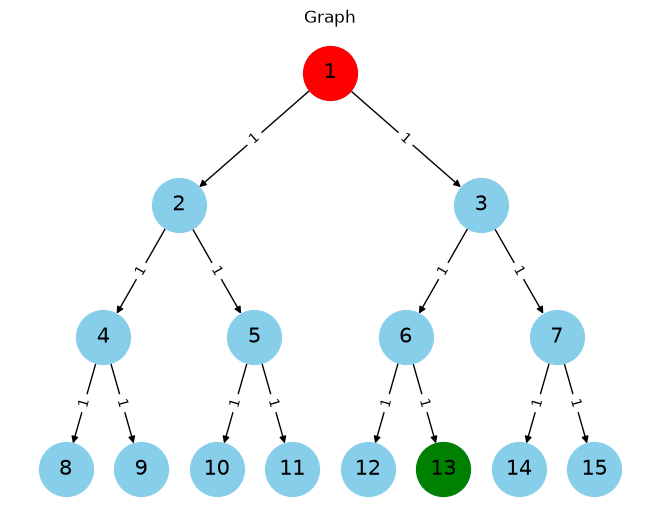

In [ ]:
from utils import Graph
edges = {
    1: [(2, 1), (3, 1)],
    2: [(4, 1), (5, 1)],
    3: [(6, 1), (7, 1)],
    4: [(8, 1), (9, 1)],
    5: [(10, 1), (11, 1)],
    6: [(12, 1), (13, 1)],
    7: [(14, 1), (15, 1)]
}
nodes = list(range(1,15))
goal_node = 13
graph = Graph(nodes,edges,start_node=1,is_tree=True,end_node = goal_node)
graph.show()


# DFS

In [ ]:
def dfs(edges,current):
    if current == goal_node:
        print("\nSolution found at node", current)
        return True
    if current not in edges:
        print(current, end=" ")
        return False
    for next,cost in edges[current]:
        #!!!
        # If we are working with a graph, we should check if the node has already been visited.
        #!!!
        if dfs(edges,next):
            return True
    print(current, end=" ")
    return False

In [24]:
dfs(edges=graph.edges,current=graph.start_node)

8 9 4 10 11 5 2 12 
Solution found at node 13
13 6 14 15 7 3 1 

False

## Complexity
| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Depth-First Search (DFS) | $No$ | $No$ | $O(b^m)$ | $O(bm)$ | Stack |

### Time Complexity

The total number of nodes explored up to depth \(m\) is:
$$
1 + b + b^2 + \cdots + b^m
$$
Using the geometric series formula:
$$
1 + b + b^2 + \cdots + b^m
= \frac{b^{m+1}-1}{b-1}
\approx b^m
$$
Therefore, the time complexity is:
$$
\boxed{O(b^m)}
$$


# BFS

In [ ]:
def bfs(edges,start_node):
    queue = [start_node]

    while queue:
        current = queue.pop(0)
        if current == goal_node:
            print("\nSolution found at node", current)
            return True
        print(current,end = " ")

        if current not in edges:
            continue

        for next,cost in edges[current]:
            #!!!
            # If we are working with a graph, we should check if the node has already been visited.
            #!!!
            queue.append(next)

    return False

In [28]:
bfs(edges=graph.edges,start_node=graph.start_node)

1 2 3 4 5 6 7 8 9 10 11 12 
Solution found at node 13
13 14 15 

False

## Complexity

| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Breadth-First Search (BFS) | $Yes^*$ (if b $\le ∞$ )|  $Yes^*$ (if cost step = 1)  | $O(b^{d+1})$ | $O(b^{d+1})$ | Queue |  


# UCS

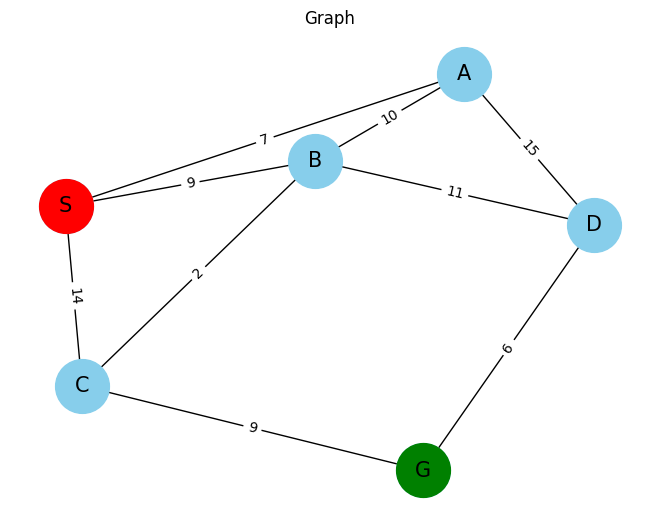

In [6]:

edges = {
    "S": [("A", 7), ("B", 9),("C",14)],
    "A": [("B", 10), ("D", 15)],
    "B": [("C", 2), ("D", 11)],
    "C": [("G", 9)],
    "D":[("G",6)]
}
nodes = ["S","A","B","C","G"]

graph = Graph(nodes,edges,start_node="S",end_node="G")
graph.show()

In [7]:
edges_bidirectional ={}

for node,successors in edges.items():
    for successor,cost in successors:
        if node not in edges_bidirectional:
            edges_bidirectional[node] = []
        if successor not in edges_bidirectional:
            edges_bidirectional[successor] = []

        edges_bidirectional[node].append((successor,cost))
        edges_bidirectional[successor].append((node,cost))


In [ ]:
from heapq import heappush,heappop

def ucs(edges, start_node, end_node):
    # current_cost, current, path
    queue = [
        (0, start_node, [start_node])
        ]
    optimal_costs = {start_node:0}
    while queue:
        current_cost, current, path = heappop(queue)
        if current == end_node:
            return current_cost, path 

        if optimal_costs[current] < current_cost:
            continue

        print(current,end = " ")

        if current not in edges:
            continue

        for next,next_cost in edges[current]:
            total_cost = current_cost + next_cost
            if next in optimal_costs and optimal_costs[next] <= total_cost:
                continue

            optimal_costs[next]=total_cost
            # The path + [next] is inefficient. We could improve it but the code will get messier.
            heappush(queue,(total_cost, next,path + [next]))


In [ ]:
ucs(edges_bidirectional, graph.start_node, graph.end_node)

S A B C D 

(20, ['S', 'B', 'C', 'G'])

## Complexity

| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Uniform-Cost Search (UCS) | $Yes$ | $Yes$ (if cost $\gt 0$ ) | $O(b^{\lceil C^*/ε \rceil})$ | $O(b^{\lceil C^*/ε \rceil})$ | Priority Queue  |

### Time and Space Complexity
- number of nodes with total cost ≤ cost of optimal solution, $O(b^{\lceil C^*/ε \rceil})$ where C* is the cost of the optimal solution and ε is the cost of the shortest edge

# DLS

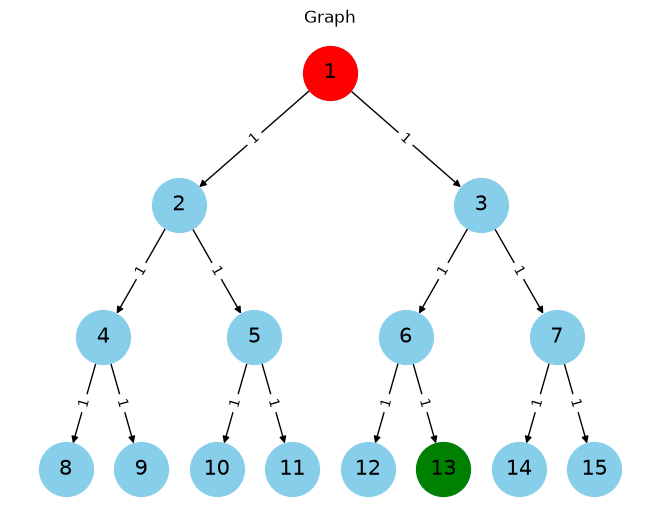

In [38]:
edges = {
    1: [(2, 1), (3, 1)],
    2: [(4, 1), (5, 1)],
    3: [(6, 1), (7, 1)],
    4: [(8, 1), (9, 1)],
    5: [(10, 1), (11, 1)],
    6: [(12, 1), (13, 1)],
    7: [(14, 1), (15, 1)]
}
nodes = list(range(1,15))

goal_node = 13
graph = Graph(nodes,edges,start_node=1,is_tree=True,end_node = goal_node)
graph.show()


In [39]:
def dls(edges,current,remaining_depth):
    if current == goal_node:
        print("\nSolution found at node", current)
        return True
    if  remaining_depth == 0 or current not in edges:
        print(current, end=" ")
        return
    for next,cost in edges[current]:
        #!!!
        # If we are working with a graph, we should check if the node has already been visited.
        #!!!
        if dls(edges,next,remaining_depth-1):
            return True
    print(current, end=" ")
    return False

In [40]:
dls(graph.edges,graph.start_node,2)

4 5 2 6 7 3 1 

False

## Complexity

| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Depth-Limited Search (DLS) | $Yes^*$ if $l\ge d$ | $No$ | $O(b^l)$ | $O(bl)$ | Stack  |

# IDS

In [41]:
def ids(edges,start_node,max_depth):
    for i in range(0,max_depth):
        if dls(edges,start_node,i):
            return
        print()

In [42]:
ids(graph.edges,graph.start_node,4)

1 
2 3 1 
4 5 2 6 7 3 1 
8 9 4 10 11 5 2 12 
Solution found at node 13


## Complexity
| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Iterative Deepening Search (IDS) | $Yes$ | $Yes$ | $O(b^d)$ | $O(bd)$ | Stack  |

### Time Complexity

Time Complexity at:

$$ Depth_0 = 1 ; Depth_1 = 1+b ; Depth_2 = 1+b+b^2$$

Therefore:
$$
S(d)=1+(1+b)+(1+b+b^2)+\cdots+(1+b+\cdots+b^d)
$$

### Step 1: Count how many times each level is visited

Rearranging the terms:

$$
S(d)
=
(1+1+\cdots+1)
+
(b+b+\cdots+b)
+
(b^2+b^2+\cdots)
+\cdots+
b^d
$$

The nodes at depth:

* $ 0 $ are visited $d+1$ times
* $ 1 $ are visited $d$ times
* $ 2 $ are visited $d-1$ times
* $ d $ are visited $1$ time

Therefore:

$$
T(d)
=
(d+1)+db+(d-1)b^2+\cdots+2b^{d-1}+b^d =\sum_{i=0}^{d}(d-i+1)b^i
$$

### Step 2: Look at the dominant term

The largest term is:

$$
b^d
$$

The terms before it are:

$$
2b^{d-1},\quad 3b^{d-2},\quad 4b^{d-3},\ldots
$$

Factor out $b^d$:

$$
T(d)
=
b^d
\left(
1+\frac{2}{b}+\frac{3}{b^2}+\frac{4}{b^3}+\cdots
\right)
$$

For $b>1$, the expression in parentheses is bounded by a constant as $d$ grows.

Therefore:

$$
T(d)=\Theta(b^d)
$$

and consequently:

$$
\boxed{O(b^d)}
$$

Thus, the time complexity of **Iterative Deepening** is:

$$
\boxed{\text{Time Complexity: }O(b^d)}
$$

# Summay of Algorithms

| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Depth-First Search (DFS) | $No$ | $No$ | $O(b^m)$ | $O(bm)$ | Stack |
| Breadth-First Search (BFS) | $Yes^*$ (if b $\le ∞$ )|  $Yes^*$ (if cost step = 1)  | $O(b^{d+1})$ | $O(b^{d+1})$ | Queue |  
| Uniform-Cost Search (UCS) | $Yes$ | $Yes$ | $O(b^{\lceil C^*/ε \rceil})$ | $O(b^{\lceil C^*/ε \rceil})$ | Priority Queue  |
| Depth-Limited Search (IDS) | $Yes^*$ if $l\ge d$ | $No$ | $O(b^l)$ | $O(bl)$ | Stack  |
| Iterative Deepening Search (IDS) | $Yes$ | $Yes$ | $O(b^d)$ | $O(bd)$ | Stack  |

# Exercise: Frog Leap Puzzle

The game has 2N + 1 fields of play. In the beginning of the
game there are N frogs which are looking to the left and
placed on the rightmost N fields, and N frogs which are
looking to the right and placed on the leftmost fields. The
aim of the game is to swap the places of the frogs and
reach the opposite configuration.

The rules of play are as follows: Each frog can only move in
the direction it looks at. Every frog can jump in a free field
in front of it or jump over a frog to go to an empty field in
front of it.

- Sample Input:
  
```2```
- Sample Output:
  
```
>>_<<
>_><<
><>_<
><><_
><_<>
_<><>
<_><>
<<>_>
<<_>>
```

### Game Tree
![frog_leap.png](images/frog_leap.png)


In [3]:
n = 2
start = ['>']*n + ['_'] + ['<']*n
end = ['<']*n + ['_'] + ['>']*n

def swap(board, i, j):
    board[i], board[j] = board[j], board[i]


def is_solved(board):
    # Note that we could rewrite the dfs to keep track of the frogs that are in correct place to avoid linear checks
    # I keep the code simple for clarity.
    return board == end

result = []

def dfs_frogs(board, empty):
    # This is the basic DFS solution for this problem
    # It explores all possible moves until it finds a solution
    
    if is_solved(board):
        result.append(''.join(board))
        return True
    
    for i in [empty-2, empty+2, empty+1, empty-1]:
        if i < 0 or i >= len(board) or (i < empty and board[i] == '<') or (i > empty and board[i] == '>'):
            continue
        
        swap(board, empty, i)

        if dfs_frogs(board, i):
            swap(board, empty, i)
            result.append(''.join(board))
            return True
        
        #backtracking
        swap(board, empty, i)

    return False


In [4]:
dfs_frogs(start, n)
for step in reversed(result):
   print(step)

>>_<<
>><_<
>_<><
_><><
<>_><
<><>_
<><_>
<_<>>
<<_>>


In [ ]:
n = 2
start = ['>']*n + ['_'] + ['<']*n
end = ['<']*n + ['_'] + ['>']*n

def swap(board, i, j):
    board[i], board[j] = board[j], board[i]


def is_solved(board):
    # Note that we could rewrite the bfs to keep track of the frogs that are in correct place to avoid linear checks
    # I keep the code simple for clarity.
    return board == end

def bfs_frogs(board, empty):
    # This is the basic BFS solution for this problem
    # It explores all possible moves until it finds a solution
    
    queue = [(board, empty, [])]

    while queue:
        current_board, current_empty, path = queue.pop(0)

        if is_solved(current_board):
            return path

        for i in [current_empty-2, current_empty+2, current_empty+1, current_empty-1]:
            if i < 0 or i >= len(current_board) or (i < current_empty and current_board[i] == '<') or (i > current_empty and current_board[i] == '>'):
                continue

            # Often in bfs algorithms, we need to create a new state instead of modifying the current one. 
            # In practice this makes the algorithm slower, and it can make DFS (with in-place backtracking) 
            # a better choice for some problems.
            new_board = current_board.copy()
            swap(new_board, current_empty, i)
            queue.append((new_board, i, path + [''.join(current_board)]))

    return False


In [6]:
bfs_frogs(start, n)
for step in reversed(result):
   print(step)

>>_<<
>><_<
>_<><
_><><
<>_><
<><>_
<><_>
<_<>>
<<_>>


# DFS vs BFS

In [8]:
import time
n = 15
start = ['>']*n + ['_'] + ['<']*n
end = ['<']*n + ['_'] + ['>']*n

start_time = time.time()
dfs_frogs(start, n)
end_time = time.time()
print(f"DFS: Time taken: {end_time - start_time} seconds")

start_time = time.time()
bfs_frogs(start, n)
end_time = time.time()
print(f"BFS: Time taken: {end_time - start_time} seconds")

DFS: Time taken: 0.12798047065734863 seconds
BFS: Time taken: 2.3841660022735596 seconds


This problem has a linear solution. You can try to find it.